In [1]:
import sys
sys.path.append('C:/Users/Lenovo/Desktop/2024_E/tools/')
from CM_dataset import CM_dataset
from load_array import LoadArray
from mxnet import autograd,gluon,init
from animator import Animator

In [2]:
CM_data = CM_dataset(1000)

In [3]:
batch_size = 16
data_loader = LoadArray(CM_data,batch_size)

In [4]:
model = gluon.nn.Sequential()
model.add(

    # gluon.nn.Dense(64, activation='relu'),
    gluon.nn.Dense(3),
    # gluon.nn.Dropout(0.1),
    gluon.nn.Dense(1)

)
model.initialize(init.Normal(sigma=0.01))

In [5]:
loss_func = gluon.loss.L2Loss()
optimizer = gluon.Trainer(model.collect_params(),'adam',{'learning_rate':0.001})

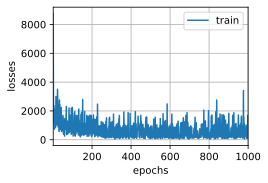

In [6]:
epochs = 1000
animator = Animator(xlabel='epochs',ylabel='losses',legend=['train'],xlim=[1,epochs])
for epoch in range(epochs):
    for feature, label in data_loader:
            with autograd.record():
                l = loss_func(model(feature),label)
                # print(feature,model(feature))
            l.backward()
            optimizer.step(batch_size)
            temp = l.mean().item()
    animator.add(epoch+1, (temp,))                

In [7]:
model[0].weight.data()

array([[-1.1659790e+00,  1.5787426e+00,  8.0792344e-04],
       [ 1.1696787e+00, -1.6056808e+00, -2.0601926e-02],
       [-1.1604601e+00,  1.5941397e+00,  1.3689983e-02]])

array([[180.20532]])

In [9]:
from mxnet import np,npx
npx.set_np()

# def PW(x):
#     return 13.5698 * x - 26945.79

def PW(x):
    return np.where(x < 2020, 13.5698 * x - 26945.79, 6.7849 * x - 13240.29)

#def PP(x):
 #   return 6.9615 * x - 13807.91
def PP(x):
    return np.where(x < 2020, 6.9615 * x - 13807.91, 20.8845 * x - 41932.37)

a = np.arange(1980,2050,1)
pw = PW(a)
pp = PP(a)

x = tuple(a.tolist())
pw = tuple(pw.asnumpy().tolist())
pp = tuple(pp.asnumpy().tolist())

animator_2 = Animator(xlabel='Year',ylabel='PW/PP(million tons)',legend=['PW','PP'],xlim=[1980,2050],ylim=[-50,1000])
for i, pw_val,pp_val in zip(x,pw,pp):
    animator_2.add(i,[pw_val,pp_val])